# Data Loading and Processing

This notebook demonstrates how to load and process raw hyperspectral data for use with the `spectral_select` library.

**What you'll learn:**
- Load raw `.im3` hyperspectral files
- Apply spectral cutoffs (Rayleigh and second-order)
- Normalize by exposure time and laser power
- Save processed data to pickle format
- Load processed data with `SpectraData`

## 1. Setup

Import the data processing utilities from `mehsi_preprocessor.io` (see `docs/onboarding/SETUP.md` for the Java/PyImageJ requirements, and `examples/03_hsi_data_walkthrough.ipynb` for a longer tour of the data layer):

In [1]:
from pathlib import Path

# Repository root (this notebook lives in examples/)
project_root = Path.cwd().parent

# The raw-data tools live in the mehsi_preprocessor package (reading .im3 needs PyImageJ: pip install -e ".[im3]")
from mehsi_preprocessor.io.hyperspectral_loader import HyperspectralDataLoader
from mehsi_preprocessor.io.hyperspectral_processor import HyperspectralProcessor
from spectral_select import SpectraData

## 2. Configure Paths

Set up paths to your raw data and metadata files:

In [2]:
# === UPDATE THESE PATHS FOR YOUR DATA ===

# Directory containing .im3 files (named by excitation wavelength, e.g., "365.0.im3")
DATA_DIR = project_root / "Data" / "Raw" / "Lichens_2"

# Excel file with exposure times (columns: Excitation, Exposure)
METADATA_PATH = DATA_DIR / "metadata.xlsx"

# Excel file with laser power measurements (columns: Excitation Wavelength (nm), Average Power (W))
LASER_POWER_PATH = DATA_DIR / "TLS Scans" / "average_power.xlsx"

# Output directory for processed data
OUTPUT_DIR = project_root / "Data" / "processed" / "Lichens_2_reprocessed"

# Spectral cutoff offset in nm
CUTOFF_OFFSET = 40

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory: /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2
Output directory: /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/processed/Lichens_2_reprocessed


## 3. Method A: Full Pipeline Processing

Use `HyperspectralProcessor` for a complete processing pipeline including:
- Spectral cutoff (Rayleigh + second-order)
- Exposure time normalization
- Laser power normalization

In [3]:
# Create processor
processor = HyperspectralProcessor(
    data_path=str(DATA_DIR),
    metadata_path=str(METADATA_PATH),
    laser_power_excel=str(LASER_POWER_PATH),
    cutoff_offset=CUTOFF_OFFSET,
    verbose=True,
)

# Run full pipeline
output_files = processor.process_full_pipeline(
    output_dir=str(OUTPUT_DIR),
    exposure_reference="max",  # Normalize to max exposure time
    power_reference="min",     # Normalize to min laser power
    create_parquet=False,
    preserve_full_data=True,
)

print("\nGenerated files:")
for name, path in output_files.items():
    print(f"  {name}: {path}")

Initializing ImageJ (Fiji)...


[ERROR] Cannot create plugin: org.scijava.plugins.scripting.javascript.JavaScriptScriptLanguage



=== Step 1: Loading data with dual cutoff (offset: 40nm) ===
Loading 310.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/310.im3


Operating in headless mode - the original ImageJ will have limited functionality.


Loading 325.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/325.im3
Loading 340.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/340.im3
Loading 365.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/365.im3
Loading 385.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/385.im3
Loading 400.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/400.im3
Loading 415.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/415.im3
Loading 430.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clusterin

In [4]:
# View data summary
processor.print_summary()


=== Hyperspectral Processing Summary ===

Data Status:
  Raw data loaded: Yes
  Cutoff applied: Yes
  Exposure normalized: Yes
  Power normalized: Yes

Normalization Information:
  Exposure times: 8 excitation wavelengths
  Exposure range: 12.50 - 5432.90
  Laser powers: 8 excitation wavelengths
  Laser power range: 0.00030540W - 0.01531000W

Output Files:
  Cutoff data: /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/processed/Lichens_2_reprocessed/data_dual_cutoff_40nm.pkl
  Exposure normalized: /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/processed/Lichens_2_reprocessed/data_cutoff_40nm_exposure_max.pkl
  Power normalized: /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/processed/Lichens_2_reprocessed/data_cutoff_40nm_exposure_max_power_min.pkl

Cutoff Details:
  Rayleigh cutoff offset: 40nm
  Second order cutoff offset: 40nm

  Excitation 310.0nm:
    Data shape: (256, 348, 22)

## 4. Method B: Step-by-Step Loading

For more control, use `HyperspectralDataLoader` to load and process data step by step:

In [5]:
# Create loader (requires ImageJ/Fiji for .im3 files).
# Note: only one ImageJ gateway can exist per Python process; the processor above already started one,
# so we reuse it instead of letting the loader start a second JVM.
loader = HyperspectralDataLoader(
    data_path=str(DATA_DIR),
    metadata_path=str(METADATA_PATH),
    cutoff_offset=CUTOFF_OFFSET,
    use_fiji=False,
    verbose=True,
)
loader._ij, loader.use_fiji = processor.loader._ij, True

# Load data with spectral cutoff
data = loader.load_data(apply_cutoff=True, pattern="*.im3")

print(f"\nLoaded {len(loader.excitation_wavelengths)} excitation wavelengths:")
print(loader.excitation_wavelengths)

Loading 310.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/310.im3
Loading 325.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/325.im3
Loading 340.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/340.im3
Loading 365.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/365.im3
Loading 385.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/385.im3
Loading 400.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/Raw/Lichens_2/400.im3
Loading 415.im3 ...
IM3Reader initializing /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clusterin

In [6]:
# Access data for a specific excitation
excitation = loader.excitation_wavelengths[0]
cube, wavelengths = loader.get_cube(excitation, processed=True)

print(f"\nData for excitation {excitation}nm:")
print(f"  Cube shape: {cube.shape} (height, width, bands)")
print(f"  Emission wavelengths: {wavelengths[:5]}... ({len(wavelengths)} total)")


Data for excitation 310.0nm:
  Cube shape: (256, 348, 22) (height, width, bands)
  Emission wavelengths: [420.0, 430.0, 440.0, 450.0, 460.0]... (22 total)


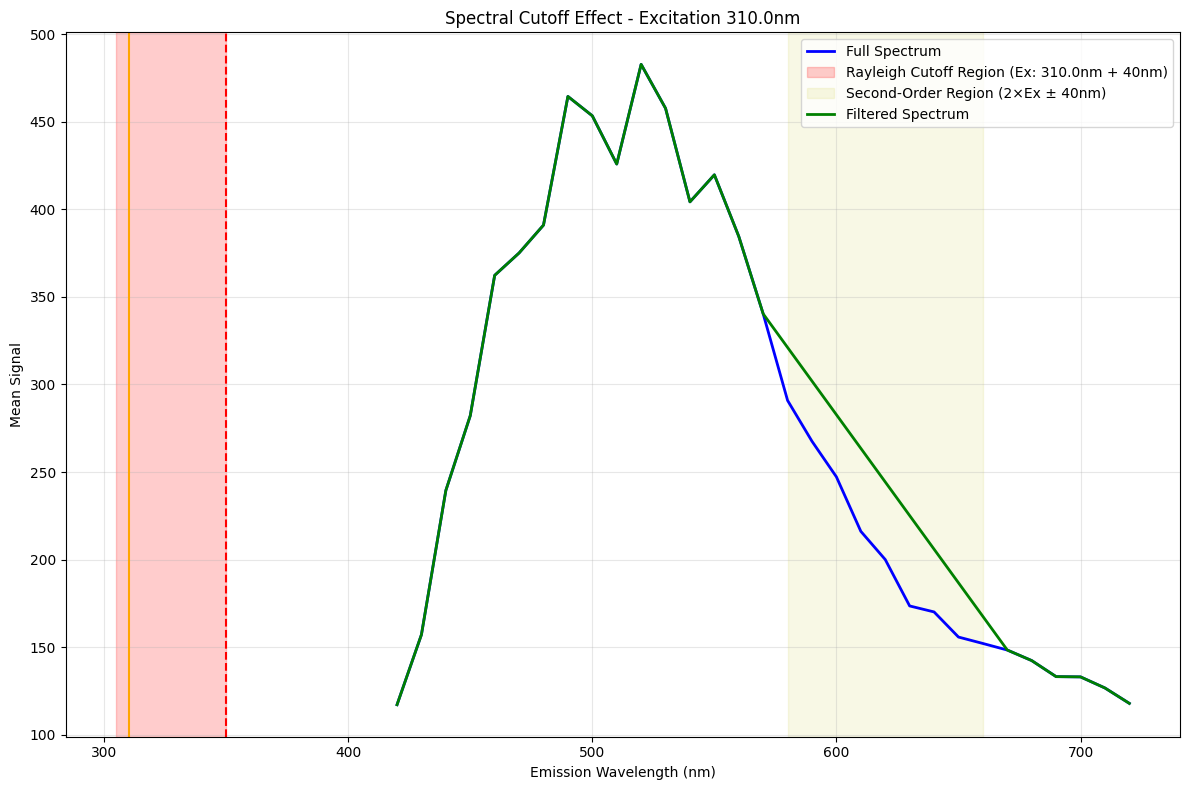

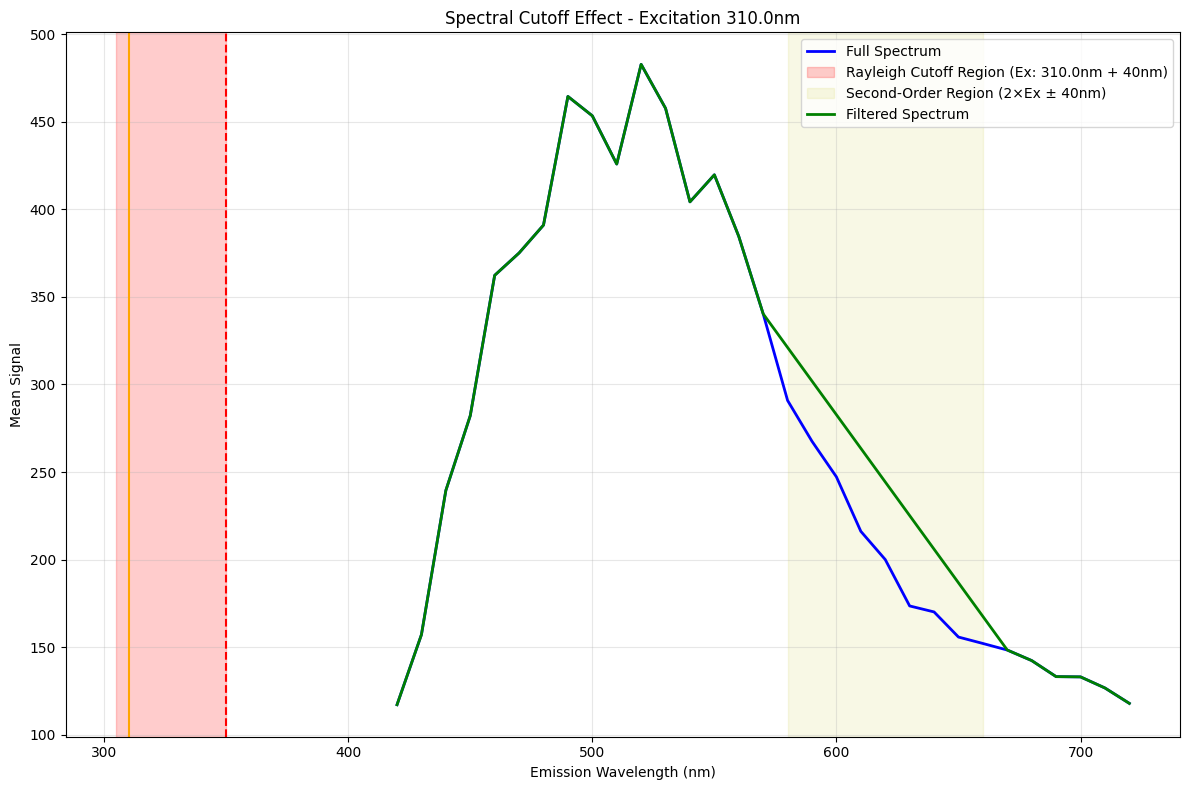

In [7]:
# Visualize the cutoff effect
loader.visualize_cutoff(excitation)

In [8]:
# Save to pickle
output_file = OUTPUT_DIR / "data_manual_processing.pkl"
loader.save_to_pkl(str(output_file))
print(f"Saved to: {output_file}")

Data saved to /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/processed/Lichens_2_reprocessed/data_manual_processing.pkl
Saved to: /Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/Data/processed/Lichens_2_reprocessed/data_manual_processing.pkl


## 5. Load Processed Data with SpectraData

Once data is saved to pickle, load it with `SpectraData.from_pickle()`:

In [9]:
# Load the processed pickle file
# Use the file generated by the processor or loader
pkl_path = OUTPUT_DIR / f"data_cutoff_{CUTOFF_OFFSET}nm_exposure_max_power_min.pkl"

data = SpectraData.from_pickle(pkl_path)

print(f"Sample: {data.sample_name}")
print(f"Spatial shape: {data.spatial_shape}")
print(f"Number of excitations: {data.n_excitations}")
print(f"Excitation wavelengths: {data.excitation_wavelengths}")

Sample: data_cutoff_40nm_exposure_max_power_min
Spatial shape: (256, 348)
Number of excitations: 8
Excitation wavelengths: [310.0, 325.0, 340.0, 365.0, 385.0, 400.0, 415.0, 430.0]


In [10]:
# Access per-excitation data
for ex_nm in data.excitation_wavelengths:
    ex_data = data.get_excitation(ex_nm)
    print(f"Ex {ex_nm:.0f}nm: {ex_data.n_bands} bands, shape {ex_data.shape}")

Ex 310nm: 22 bands, shape (256, 348, 22)
Ex 325nm: 22 bands, shape (256, 348, 22)
Ex 340nm: 22 bands, shape (256, 348, 22)
Ex 365nm: 27 bands, shape (256, 348, 27)
Ex 385nm: 30 bands, shape (256, 348, 30)
Ex 400nm: 29 bands, shape (256, 348, 29)
Ex 415nm: 29 bands, shape (256, 348, 29)
Ex 430nm: 29 bands, shape (256, 348, 29)


## 6. Visualize Spectra

Use the loader's visualization utilities to explore the data:

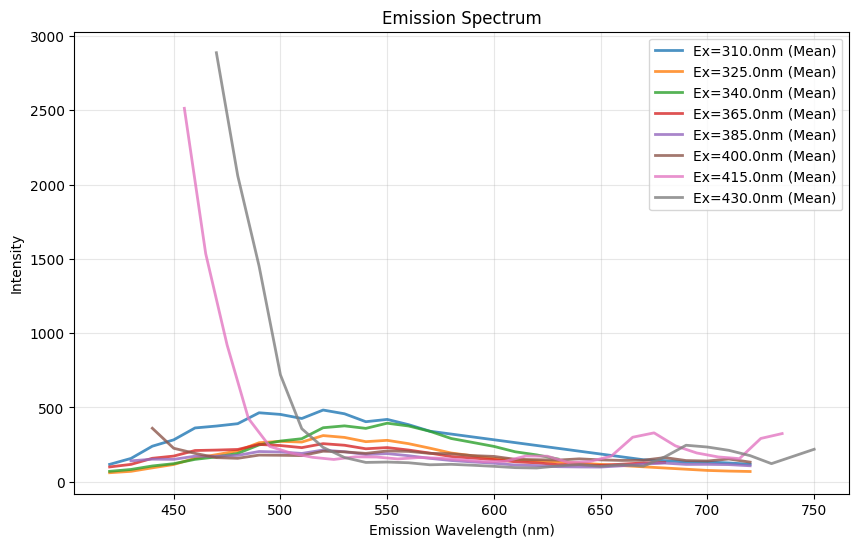

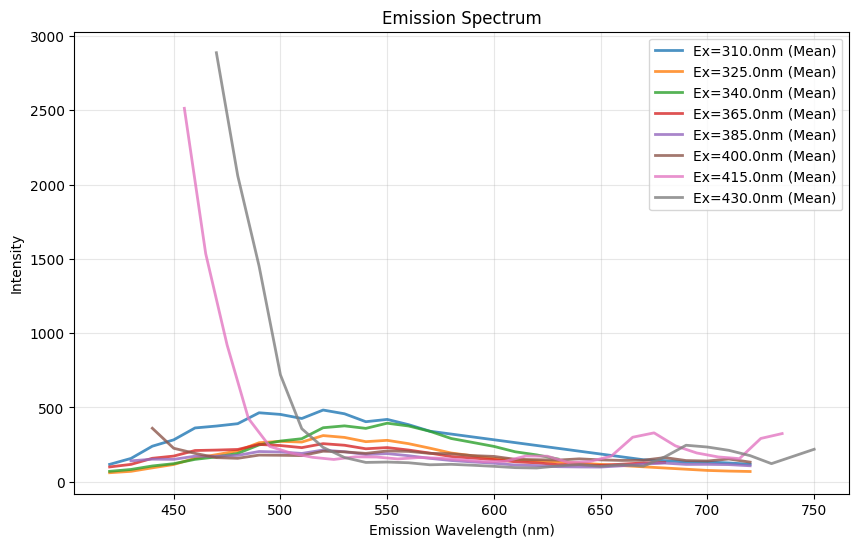

In [11]:
# Plot mean emission spectrum for all excitations
loader.visualize_spectrum(excitation=None, processed=True)

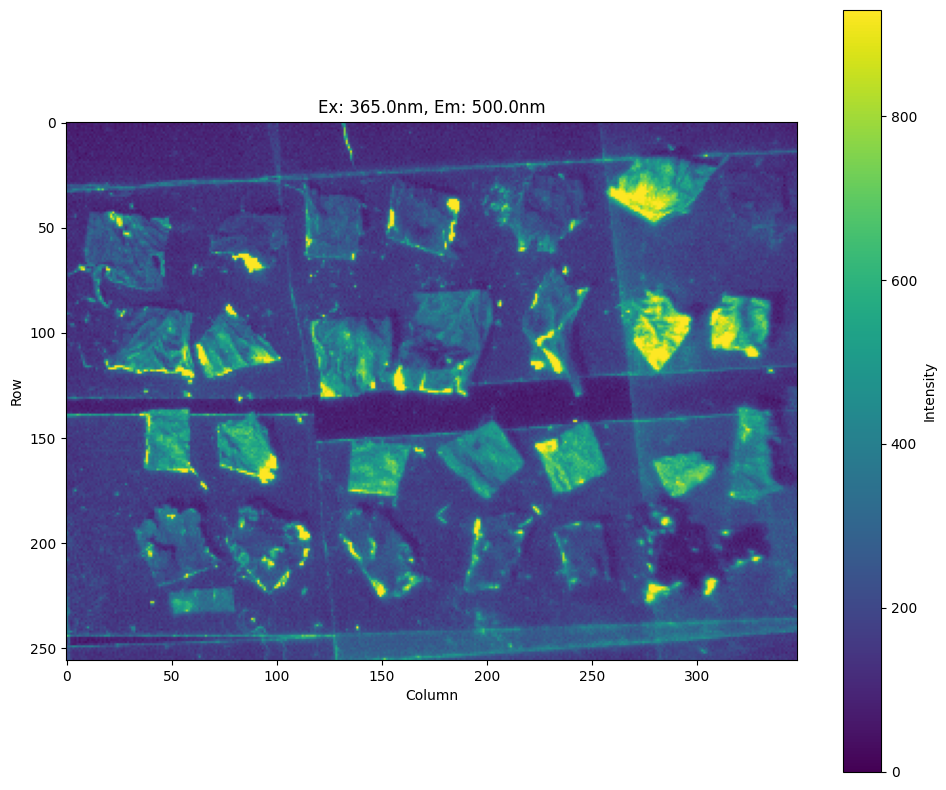

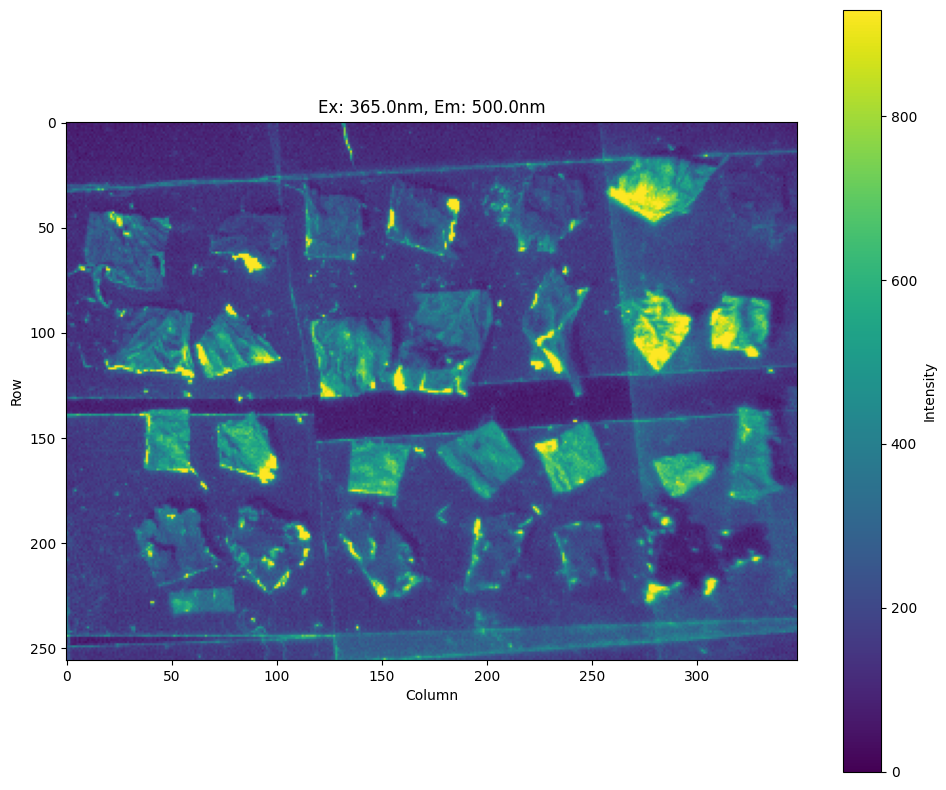

In [12]:
# Visualize a single band image
loader.visualize_image(excitation=365.0, emission_wavelength=500.0)

/Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/narekmeloyan/PycharmProjects/4D-Hyperspectral-Unsupervised-Clustering/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


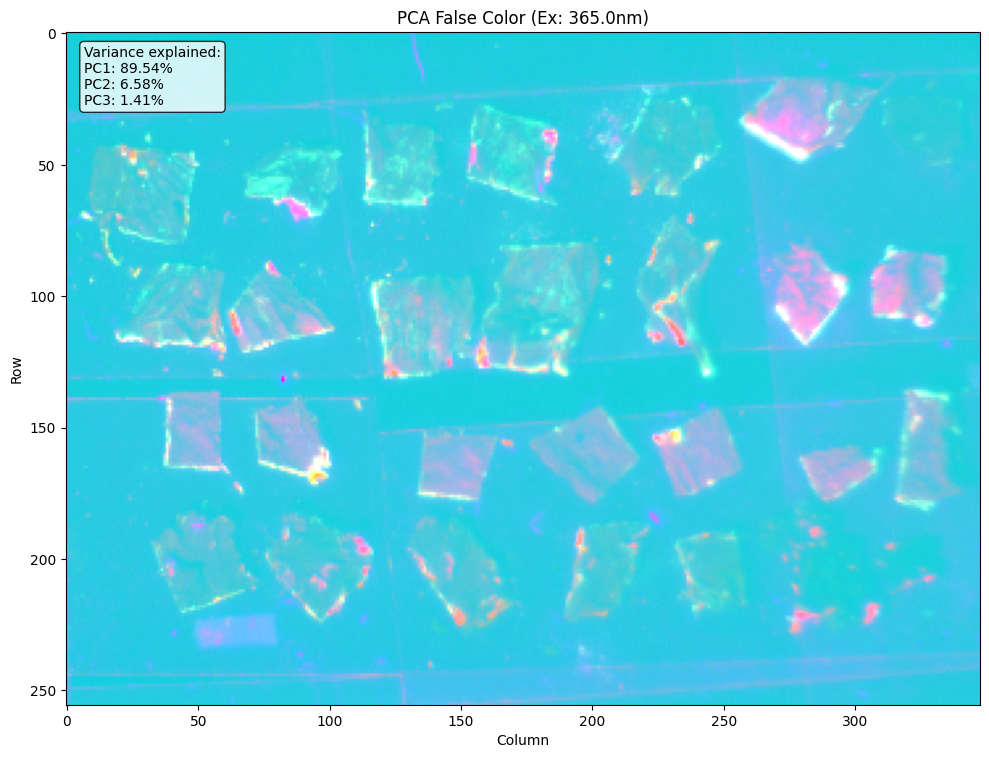

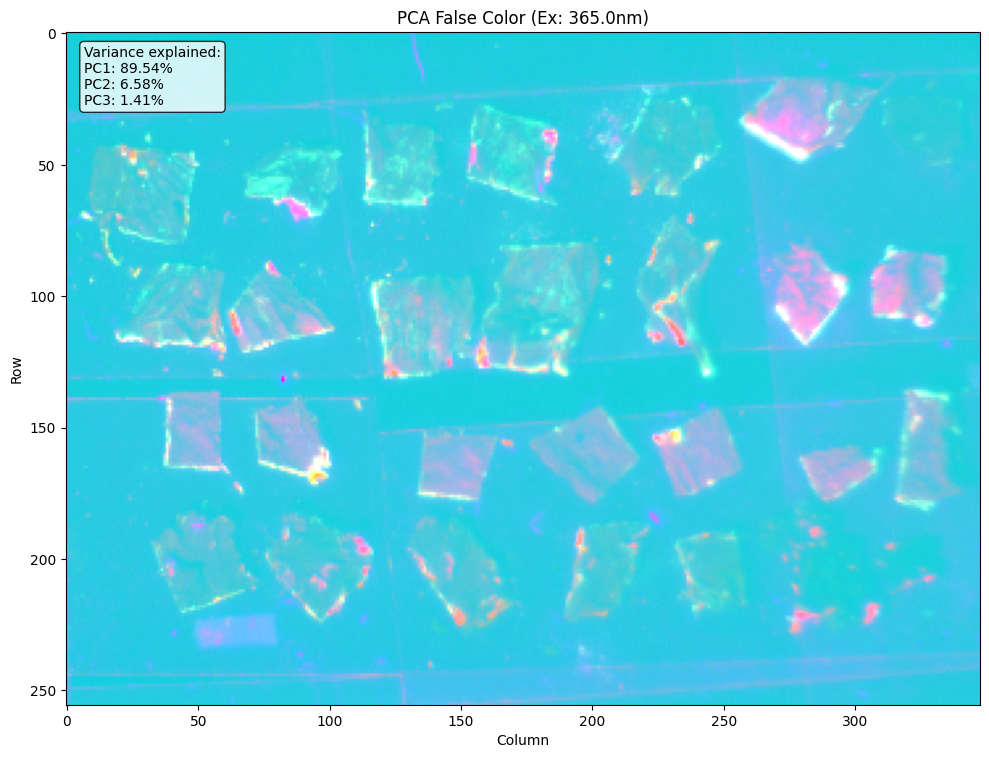

In [13]:
# Create false color visualization
loader.visualize_false_color(excitation=365.0, method='pca')

## Expected File Structure

Your raw data directory should look like this:

```
Data/Raw/YourSample/
├── 310.im3          # Named by excitation wavelength (bare number)
├── 325.im3
├── 340.im3
├── 365.im3
├── 385.im3
├── 400.im3
├── 415.im3
├── 430.im3
├── metadata.xlsx    # Columns: Excitation, Exposure
└── TLS Scans/
    └── average_power.xlsx  # Laser power measurements
```

## Pickle File Format

The saved pickle file contains:

```python
{
    'data': {
        '310.0': {
            'cube': np.ndarray,       # (H, W, bands)
            'wavelengths': [420.0, 430.0, ...],
            'excitation': 310.0,
            'raw': {...},
            'exposure_normalization_factor': float,
            'laser_power_normalization_factor': float,
        },
        '325.0': {...},
        ...
    },
    'excitation_wavelengths': [310.0, 325.0, ...],
    'metadata': {...},
    'cutoff_offset': 40,
}
```

## Summary

In this notebook, you learned how to:

1. **Full pipeline** with `HyperspectralProcessor.process_full_pipeline()`
2. **Step-by-step** with `HyperspectralDataLoader.load_data()`
3. **Save** processed data with `loader.save_to_pkl()`
4. **Load** with `SpectraData.from_pickle()`
5. **Visualize** spectra and images

**Next steps:**
- See `01_quickstart.ipynb` for running wavelength selection analysis
- See `02_validation.ipynb` for validating with ground truth